In [34]:
#imports
import pandas as pd
import os
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
from wordcloud import WordCloud
import re

Nota: Deviamos ter adicionado features ao dataframe em vez de fazer como fizémos :( fazer depois na próxima fase

In [35]:
# Select channel
channel = 'TVI'

#select date
date = 'Nov_10'


## Load OCR data

In [36]:
# Load visual pkl for debate with person 1 and person 2 OR all debates with person 1 OR all debates
pklfiles = []

if channel and date:
    for file in os.listdir('../Project_Features'):
        if file.endswith('ocr.pkl') and channel in file and date in file:
            pklfiles.append(file) 
elif channel and not date:
    for file in os.listdir('../Project_Features'):
        if file.endswith('ocr.pkl') and channel in file:
            pklfiles.append(file)
elif date and not channel:
    for file in os.listdir('../Project_Features'):
        if file.endswith('ocr.pkl') and date in file:
            pklfiles.append(file)
else:
    for file in os.listdir('../Project_Features'):
        if file.endswith('ocr.pkl'):
            pklfiles.append(file)

data = []

for video in pklfiles:
    print(f"Loading: {video}")
    df = pd.read_pickle(os.path.join('../Project_Features', video))
    data.append(df)

data = pd.concat(data, ignore_index=True)
#data = data.sort_values(by='Frame').reset_index(drop=True)

# Extract the video folder name (everything between 'Frames/' and '/frame_')
data['Video_Name'] = data['Frame'].str.extract(r'Frames/([^/]+)/')

# Extract the actual frame number and convert it to an integer
data['Frame_Number'] = data['Frame'].str.extract(r'frame_(\d+)\.jpg').astype(int)

# Sort first by the Video Name, then by the true integer Frame Number
data = data.sort_values(by=['Video_Name', 'Frame_Number']).reset_index(drop=True)

print('\n')
data.info()

all_text = []
for idx, frame in data.iterrows():
    frame_n = frame['Frame_Number']
    video_name = frame['Video_Name']
    ocr = frame['OCR']

    if len(ocr) >0:
        for box in ocr:
            bbox = box['bbox']
            text = box['text']
            conf = box['conf']
        
    
            new_row = {'frame_n': frame_n,
                        'video_name': video_name,
                        'bbox': bbox,
                        'text': text,
                        'conf': conf}
            
            all_text.append(new_row)

df_ocr = pd.DataFrame(all_text)

print(f"\n df_ocr.head():")
print(df_ocr.head())
        

Loading: Telejornal_TVI_Nov_10_ocr.pkl


<class 'pandas.DataFrame'>
RangeIndex: 4317 entries, 0 to 4316
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Frame         4317 non-null   str   
 1   OCR           4317 non-null   object
 2   Video_Name    4317 non-null   str   
 3   Frame_Number  4317 non-null   int64 
dtypes: int64(1), object(1), str(2)
memory usage: 404.9+ KB

 df_ocr.head():
   frame_n             video_name                          bbox  \
0        1  Telejornal_TVI_Nov_10  [296.0, 506.0, 993.0, 582.0]   
1        3  Telejornal_TVI_Nov_10  [207.0, 357.0, 716.0, 483.0]   
2        4  Telejornal_TVI_Nov_10     [222.0, 8.0, 262.0, 21.0]   
3        4  Telejornal_TVI_Nov_10  [203.0, 209.0, 266.0, 242.0]   
4        4  Telejornal_TVI_Nov_10  [236.0, 247.0, 249.0, 256.0]   

                       text      conf  
0  A TELEVISÃO FEITA POR SI  0.986565  
1        JORNAL<br>NACIONAL  0.741719  
2           

OCR collumn:
- List of dictionaries. 
- Dictionaries keys: 
    - 'bbox': A list of 4 numbers [x1, y1, x2, y2] representing the corners of the box drawn around the detected text.  
    - 'conf': Confidence in detection
    - 'text': Text detected

## EDA

### Confidances

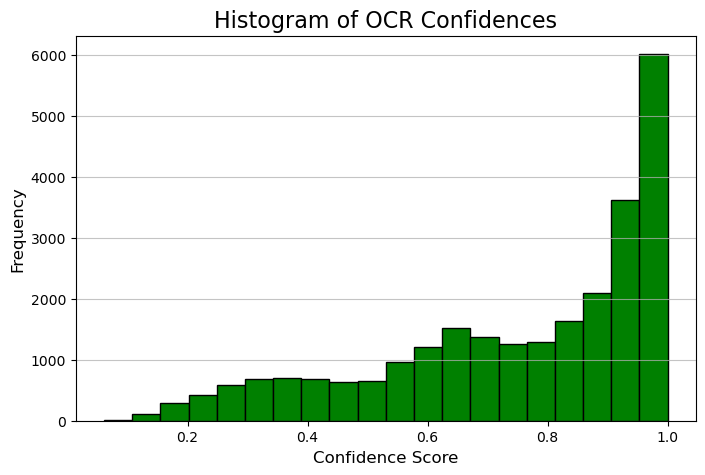

25th Percentile (Q1): 0.6069
50th Percentile (Q2/Median): 0.8295
75th Percentile (Q3): 0.9499


In [37]:
plt.figure(figsize=(8, 5))
plt.hist(df_ocr['conf'], bins=20, color='green', edgecolor='black')
plt.title('Histogram of OCR Confidences', fontsize=16)
plt.xlabel('Confidence Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.75)
plt.show()

# quartiles of confidence scores
Q1 = np.percentile(df_ocr['conf'], 25)
Q2 = np.percentile(df_ocr['conf'], 50)
Q3 = np.percentile(df_ocr['conf'], 75)

print(f"25th Percentile (Q1): {Q1:.4f}")
print(f"50th Percentile (Q2/Median): {Q2:.4f}")
print(f"75th Percentile (Q3): {Q3:.4f}")

In [38]:
# below Q1
print("--- LOW CONFIDENCE (< 0.6) ---")
print(df_ocr[df_ocr['conf'] < 0.6]['text'].sample(10).tolist())

# "middle ground" 
print("\n--- MEDIUM CONFIDENCE (0.6 to 0.8) ---")
print(df_ocr[(df_ocr['conf'] >= 0.6) & (df_ocr['conf'] < 0.8)]['text'].sample(10).tolist())

# "good stuff"
print("\n--- HIGH CONFIDENCE (> 0.8) ---")
print(df_ocr[df_ocr['conf'] >= 0.8]['text'].sample(10).tolist())

--- LOW CONFIDENCE (< 0.6) ---
['PORTUGA', '<b>Zetano</b>', 'W.', 'CHILL.', 'Ö', 'nor migné-', 'OM', 'Norauto', 'Boss', '14']

--- MEDIUM CONFIDENCE (0.6 to 0.8) ---
['<b>tvi</b> 20:11', 'Porta-voz do Governo de Israel', 'NATAL', 'LIGA<br>PORTUGA', 'METADE DO VIALOR REV', 'PARTICIPE EM tripass\n\nSINCURSO PUBLICITÁRIO 28/2025 AUTORIZADO PELA CMO. PRÉMIO EM CARTÃO, N', '0', '0.9', 'ÚLTIMA PARALISAÇÃO ACONTECEU DURANTE A TROIKA', '<b>tvi</b> 20:37']

--- HIGH CONFIDENCE (> 0.8) ---
['nirates', 'FA', '<b>CORRIDA A BELÉM</b>', 'tvi', 'TRIBUNAL NÃO CONCEDEU 48 HORAS PARA CONSULTAR PROCESSO', '<b>CRIME EM ARRAIOLOS</b>', '<b>Shosh Bedrosian</b>', '"ALGUNS JOGADORES NÃO SABEM AINDA O QUE É O BENFICA"', 'TRIBUNAL NÃO CONCEDEU 48 HORAS PARA CONSULTAR PROCESSO', '']


In [39]:
#considering texts with confidence >= threshold 
threshold = 0.6

mask = df_ocr['conf'] >= threshold
df_conf_text = df_ocr[mask]

# Compare the sizes to see how much noise was dropped
print(f"Original text blocks: {len(df_ocr)}")
print(f"Clean text blocks: {len(df_conf_text)}")

Original text blocks: 25732
Clean text blocks: 19474


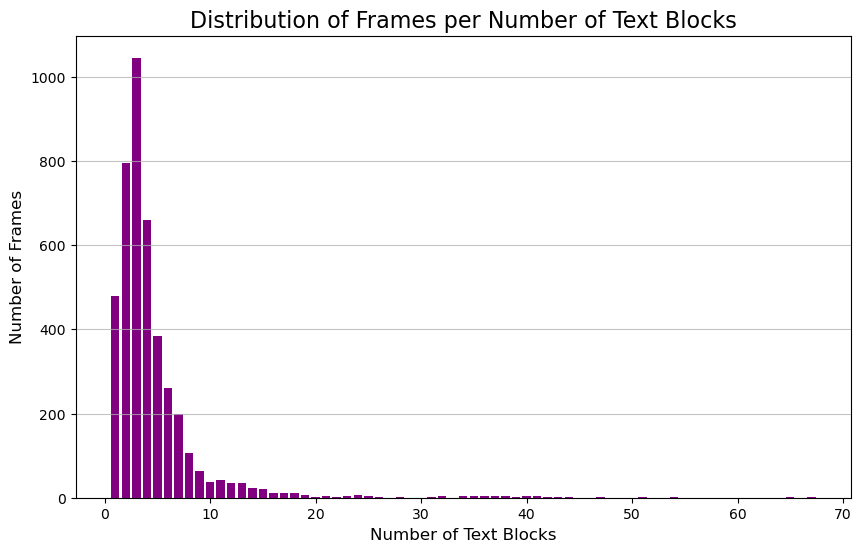

In [40]:
# Distribution of text blocks per frame
text_counts = df_conf_text.groupby('frame_n').size()
text_counts_flipped = text_counts.value_counts().sort_index()

# plot 
plt.figure(figsize=(10, 6))
plt.bar(text_counts_flipped.index, text_counts_flipped.values, color='purple')
plt.title('Distribution of Frames per Number of Text Blocks', fontsize=16)
plt.xlabel('Number of Text Blocks', fontsize=12)
plt.ylabel('Number of Frames', fontsize=12)
plt.grid(axis='y', alpha=0.75)
plt.show()


### Textual Analysis

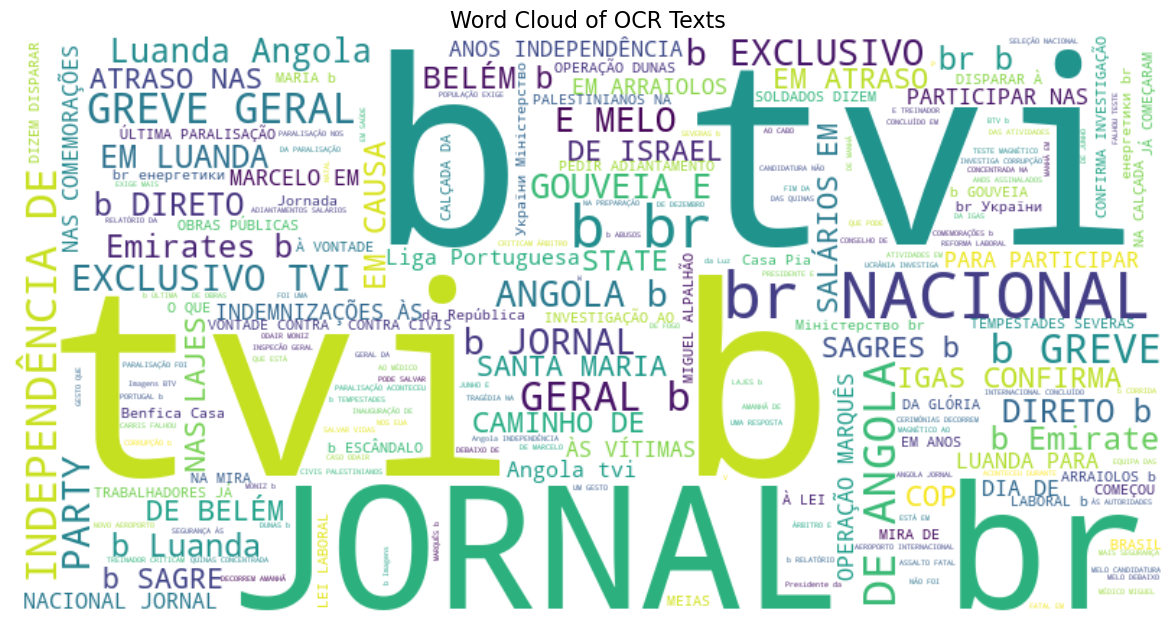

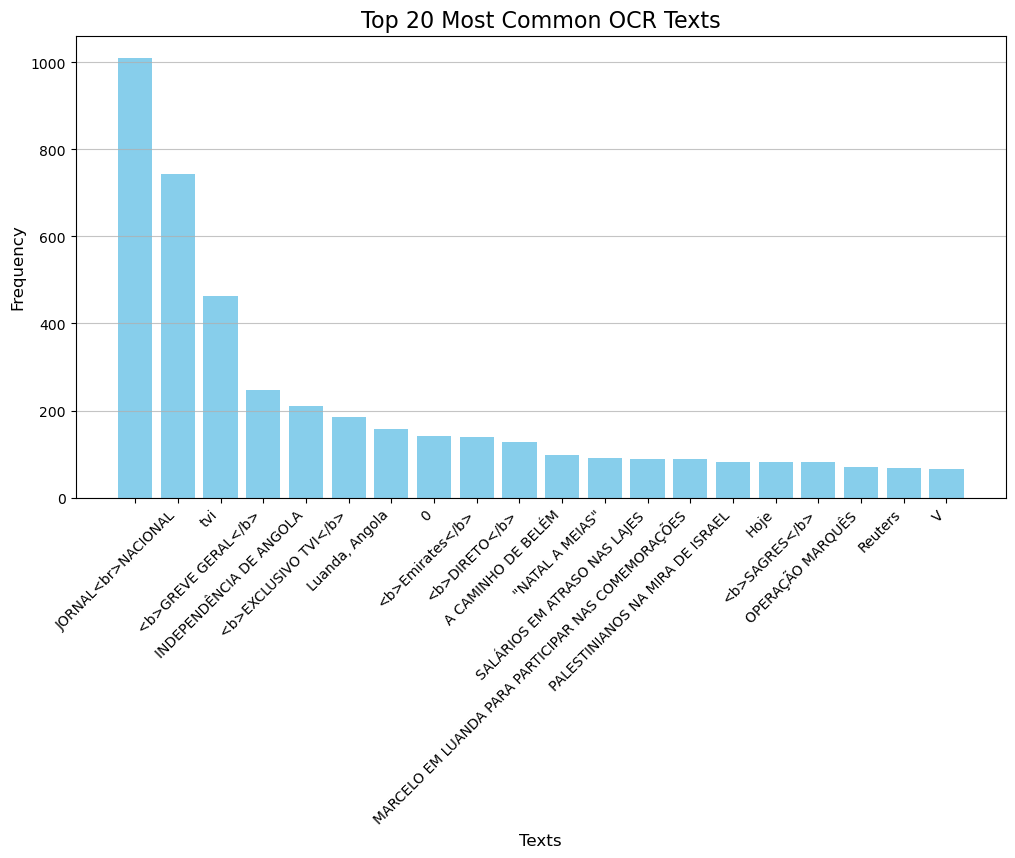

In [41]:
text_blob = ' '.join(df_conf_text['text'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_blob)

plt.figure(figsize=(15, 7.5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of OCR Texts', fontsize=16)
plt.show() 

# -------- BAR CHART with 20 most common words

top_20 = df_conf_text['text'].value_counts().head(20)

plt.figure(figsize=(12, 6))
# top_20.index contains the actual words/phrases
# top_20.values contains the frequency numbers
plt.bar(top_20.index, top_20.values, color='skyblue')

plt.title('Top 20 Most Common OCR Texts', fontsize=16)
plt.xlabel('Texts', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)
plt.show()

#### Remove Weird Symbols 

Create a mask to remove weird symbols (such as b and br) that were always appearing in the previous wordcloud and barchart

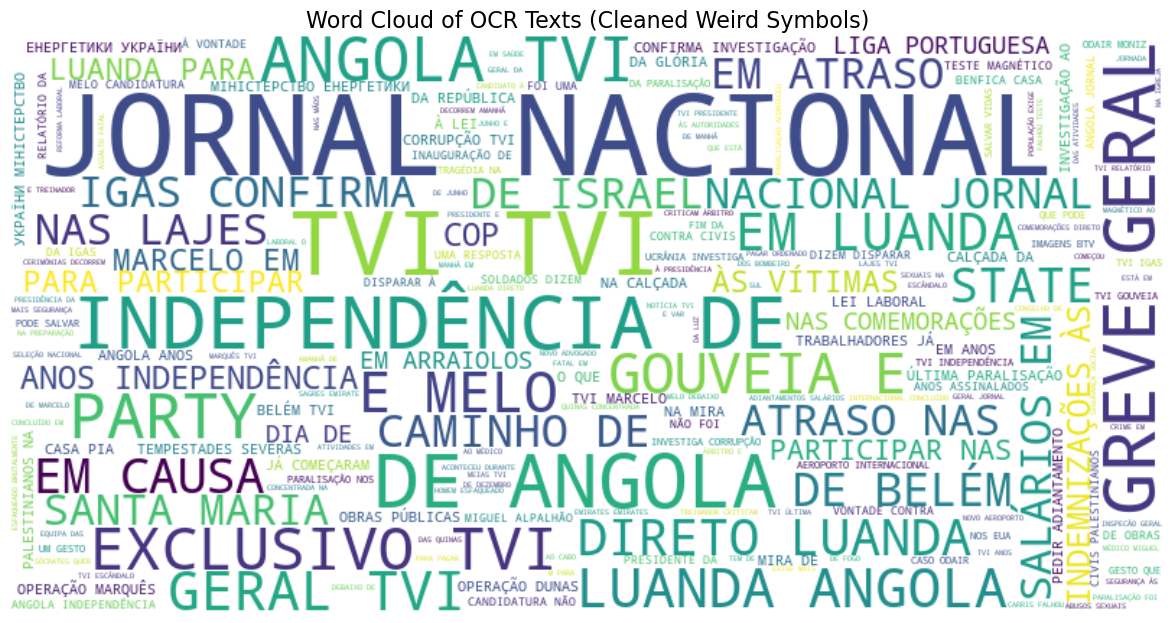

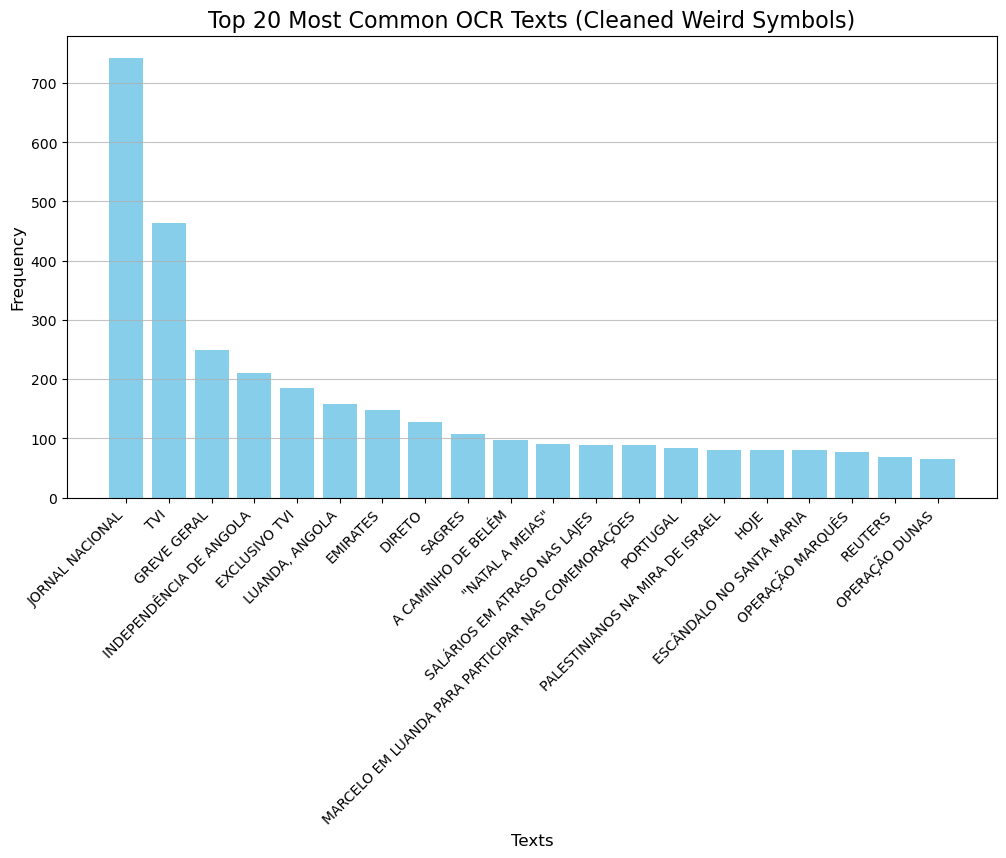

In [42]:
df_cleaned = df_conf_text.copy()

df_cleaned['text'] = df_cleaned['text'].str.replace(r'<b>|</b>|<br>|<mark>|</mark>', ' ', regex=True).str.upper().str.strip() #replace this weird thigs by ' '

df_cleaned = df_cleaned[df_cleaned['text'].str.len() > 1] #remove empty strings or strings with len=1 (havia b e 0)


text_blob_cleaned = ' '.join(df_cleaned['text'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_blob_cleaned)
plt.figure(figsize=(15, 7.5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of OCR Texts (Cleaned Weird Symbols)', fontsize=16)
plt.show() 

# -------- BAR CHART with 20 most common words

top_20 = df_cleaned['text'].value_counts().head(20)

plt.figure(figsize=(12, 6))
# top_20.index contains the actual words/phrases
# top_20.values contains the frequency numbers
plt.bar(top_20.index, top_20.values, color='skyblue')

plt.title('Top 20 Most Common OCR Texts (Cleaned Weird Symbols)', fontsize=16)
plt.xlabel('Texts', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)
plt.show()

#### Remove Clocks and Logo

Create more masks to remove the clock and words (tvi, rtp, telejornal) because they are always on the screen, making the wordcloud enphasize  them

Number of clocks caught: 4201
--- Clocks Caught ---
text
21:27    54
20:43    53
21:29    49
Name: count, dtype: int64
-----------------------------------------------------
Number of dates caught: 0
--- Dates Caught ---
Series([], Name: count, dtype: int64)
-----------------------------------------------------
Number of logos caught: 2616
--- Logos Caught ---
text
TVI              463
EXCLUSIVO TVI    185
TVI  21:17        41
NOTÍCIA TVI       40
TVI  20:00        40
Name: count, dtype: int64
-----------------------------------------------------
Number of "direto/jornal/telej" caught: 959
--- 'direto/jornal/telej' Caught ---
text
JORNAL NACIONAL                      743
DIRETO                               128
JORNAL                                17
ALEXANDRA MONTEIRO I JORNALISTA        5
O DIRETOR EXECUTIVO DA PROTEÇÃO E      5
Name: count, dtype: int64

--- Top 10 Most Frequent Texts ---
text
GREVE GERAL                                           249
INDEPENDÊNCIA DE ANGOLA         

/var/folders/5g/t8kckpys61zdtmy3jx9lt0z00000gn/T/ipykernel_41696/3579626470.py:13: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  is_date = df_cleaned['text'].str.contains(date_pattern, case=False, regex=True, na=False)


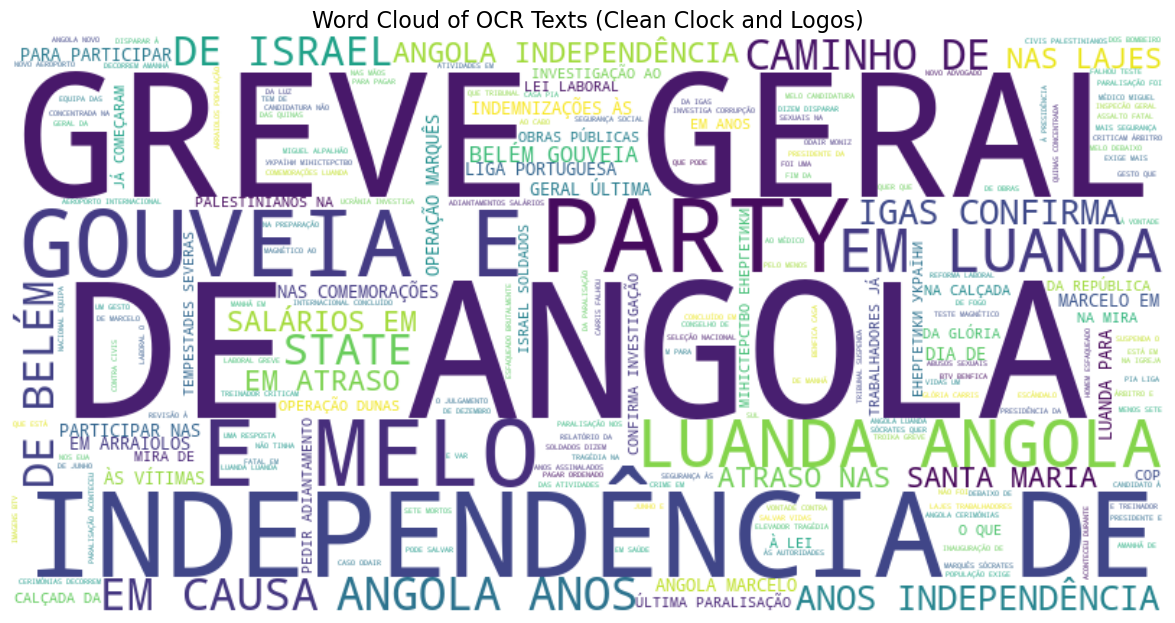

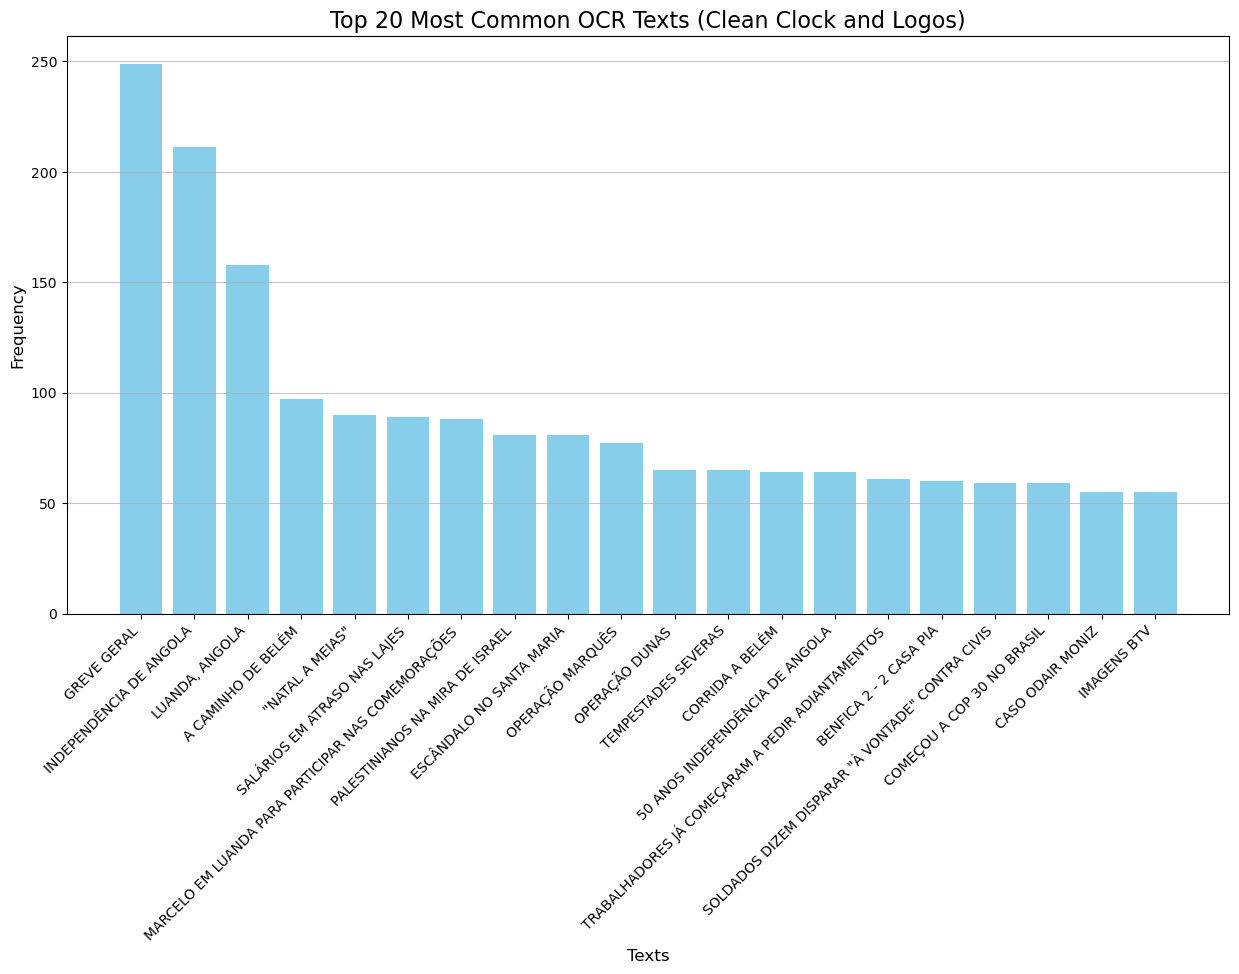

In [43]:
#regex to look for specific pattern (number number : number number)
is_clock = df_cleaned['text'].str.contains(r'\d{1,2}:\d{2}' , regex=True, na=False)

clocks_found = df_cleaned[is_clock]

print(f'Number of clocks caught: {len(clocks_found)}')
print("--- Clocks Caught ---")
print(clocks_found['text'].value_counts().head(3))
print('-----------------------------------------------------')

# dates because the clocks didn's catch some QUI, QUA etc
date_pattern = r'(seg|ter|qua|qui|sex|sab|sáb|dom)\.\s*\d{1,2}'
is_date = df_cleaned['text'].str.contains(date_pattern, case=False, regex=True, na=False)
dates_found = df_cleaned[is_date]
print(f'Number of dates caught: {len(dates_found)}')
print("--- Dates Caught ---")
print(dates_found['text'].value_counts().head(5))
print('-----------------------------------------------------')

# logos
is_logo = df_cleaned['text'].str.contains('rtp|tvi', case=False, na=False)
logos_found = df_cleaned[is_logo]
print(f'Number of logos caught: {len(logos_found)}')
print("--- Logos Caught ---")
print(logos_found['text'].value_counts().head(5))
print('-----------------------------------------------------')

# direto, telejornal, jornal, etc
is_logo2 = df_cleaned['text'].str.contains('direto|jornal|telej', case=False, na=False)
logos_found = df_cleaned[is_logo2]
print(f'Number of "direto/jornal/telej" caught: {len(logos_found)}')
print("--- 'direto/jornal/telej' Caught ---")
print(logos_found['text'].value_counts().head(5))


is_cleaner = ~(is_clock | is_logo | is_logo2 | is_date)
df_no_clock_no_logo=df_cleaned[is_cleaner]

# guarantee the titles are actually titles
df_no_clock_no_logo = df_no_clock_no_logo[df_no_clock_no_logo['text'].str.len() > 10]

print("\n--- Top 10 Most Frequent Texts ---")
print(df_no_clock_no_logo['text'].value_counts().head(10))

#Wordcloud and bar graph

text_final_clean = ' '.join(df_no_clock_no_logo['text'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_final_clean)

plt.figure(figsize=(15, 7.5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of OCR Texts (Clean Clock and Logos)', fontsize=16)
plt.show() 

# -------- BAR CHART with 20 most common words

top_20 = df_no_clock_no_logo['text'].value_counts().head(20)

plt.figure(figsize=(15, 7.5))
# top_20.index contains the actual words/phrases
# top_20.values contains the frequency numbers
plt.bar(top_20.index, top_20.values, color='skyblue')

plt.title('Top 20 Most Common OCR Texts (Clean Clock and Logos)', fontsize=16)
plt.xlabel('Texts', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.75)
plt.savefig('top_20_texts.png', bbox_inches='tight')
plt.show()

### Spatial Analysis

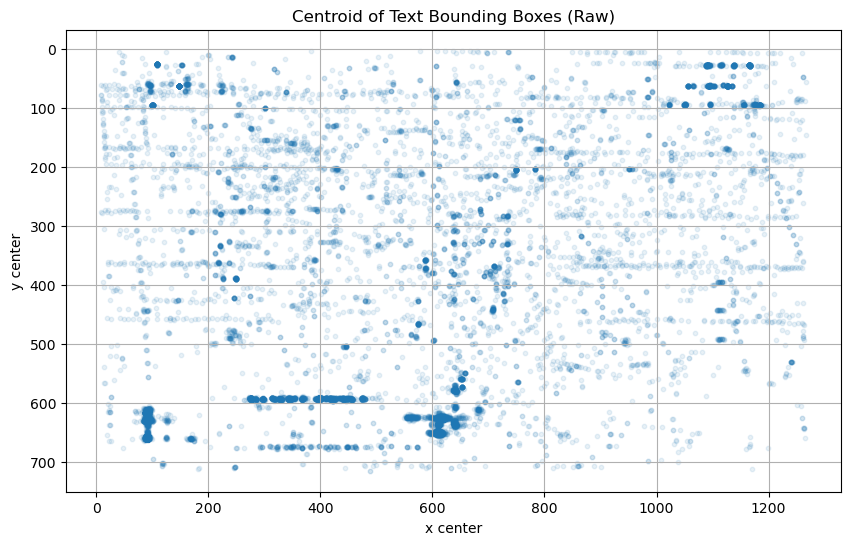

In [44]:
y_centers, x_centers = [], []

for box in df_cleaned['bbox']:
    if len(box)>0:
        x_c = (box[2]+box[0])/2
        y_c =(box[3]+box[1])/2
        x_centers.append(x_c)
        y_centers.append(y_c)

plt.figure(figsize=(10,6))
plt.scatter(x_centers, y_centers, alpha=0.1, s=10)
plt.grid(True)
plt.title('Centroid of Text Bounding Boxes (Raw)')
plt.ylabel('y center')
plt.xlabel('x center')
plt.gca().invert_yaxis() #had to invert
plt.show()


#### How can the AI detect so much text everywhere????

Given the blob of points, we understand that not only the clock+logo+header+rodapé are being detected. More words are being detected, which means more bounding boxes are appearing everywhere.

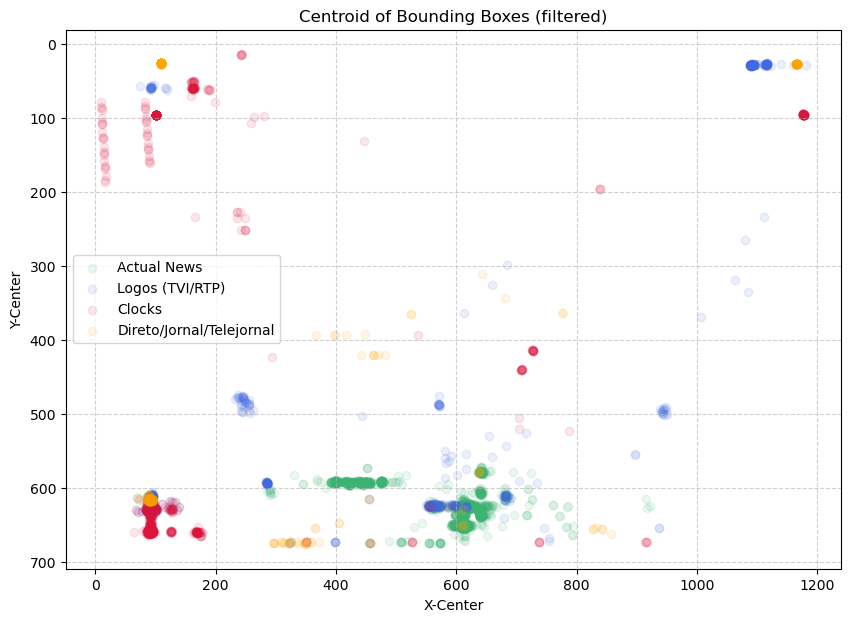

In [45]:
#add columns with centers
df_cleaned['x_center'] = (df_cleaned['bbox'].str[0] + df_cleaned['bbox'].str[2])/2
df_cleaned['y_center'] = (df_cleaned['bbox'].str[1] + df_cleaned['bbox'].str[3])/2
df_cleaned['area']= (df_cleaned['bbox'].str[3]- df_cleaned['bbox'].str[1])*(df_cleaned['bbox'].str[2]- df_cleaned['bbox'].str[0])

# bottom 30% of the screen
max_y = df_cleaned['y_center'].max()
dynamic_bottom_threshold = max_y * 0.8 
is_bottom = df_cleaned['y_center'] > dynamic_bottom_threshold

# area
dynamic_area_threshold = df_cleaned['area'].quantile(0.75)
is_area = df_cleaned['area'] > dynamic_area_threshold

# filter news
is_news = is_cleaner & is_bottom & is_area #filter this to include bigger areas which are more likely to be news text -> only keeps titles
df_news_zone = df_cleaned[is_news]


plt.figure(figsize=(10, 7))
plt.scatter(df_cleaned[is_news]['x_center'], df_cleaned[is_news]['y_center'], color='mediumseagreen', alpha=0.1, label='Actual News')
plt.scatter(df_cleaned[is_logo]['x_center'], df_cleaned[is_logo]['y_center'], color='royalblue', alpha=0.1, label='Logos (TVI/RTP)')
plt.scatter(df_cleaned[is_clock]['x_center'], df_cleaned[is_clock]['y_center'], color='crimson', alpha=0.1, label='Clocks')
plt.scatter(df_cleaned[is_logo2]['x_center'], df_cleaned[is_logo2]['y_center'], color='orange', alpha=0.1, label='Direto/Jornal/Telejornal')

plt.title(f'Centroid of Bounding Boxes (filtered)')
plt.xlabel('X-Center')
plt.ylabel('Y-Center')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.gca().invert_yaxis() #had to invert
plt.savefig('centroid_filtered.png', bbox_inches='tight')

plt.show()

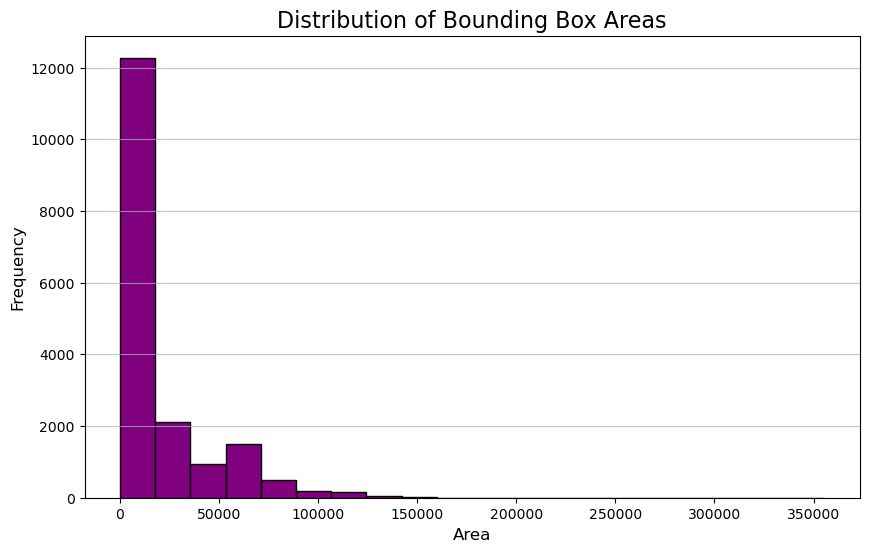

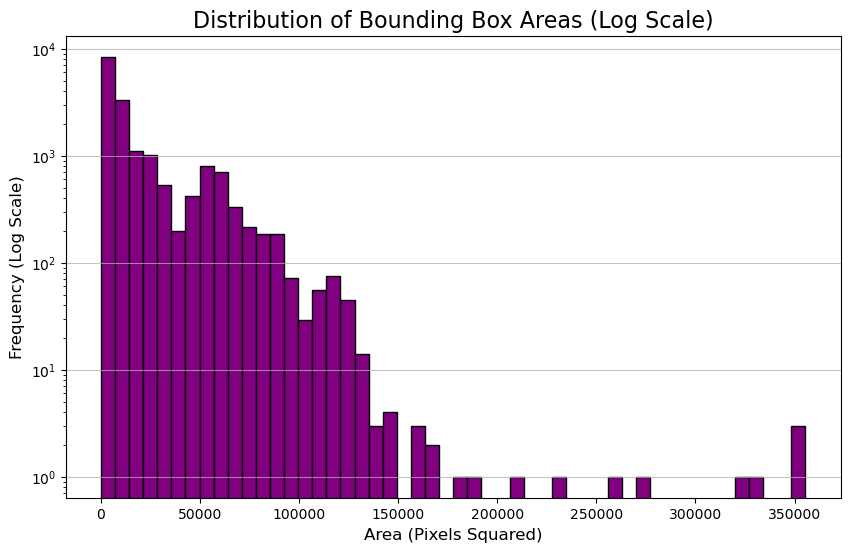

--- Area Summary Statistics ---
count     17757
mean      18887
std       25820
min          72
25%        2450
50%        7722
75%       24395
max      355473
Name: area, dtype: int64


In [46]:
plt.figure(figsize=(10, 6))
plt.hist(df_cleaned['area'], bins=20, color='purple', edgecolor='black')
plt.title('Distribution of Bounding Box Areas', fontsize=16)
plt.xlabel('Area', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(axis='y', alpha=0.75)

plt.figure(figsize=(10, 6))

# Added bins=50 for finer detail, and log=True to handle the massive skew
plt.hist(df_cleaned['area'], bins=50, color='purple', edgecolor='black', log=True)

plt.title('Distribution of Bounding Box Areas (Log Scale)', fontsize=16)
plt.xlabel('Area (Pixels Squared)', fontsize=12)
plt.ylabel('Frequency (Log Scale)', fontsize=12)
plt.grid(axis='y', alpha=0.75)
plt.show()

# Print the statistical summary to see your quartiles!
print("--- Area Summary Statistics ---")
print(df_cleaned['area'].describe().astype(int))

### Temporal Analysis

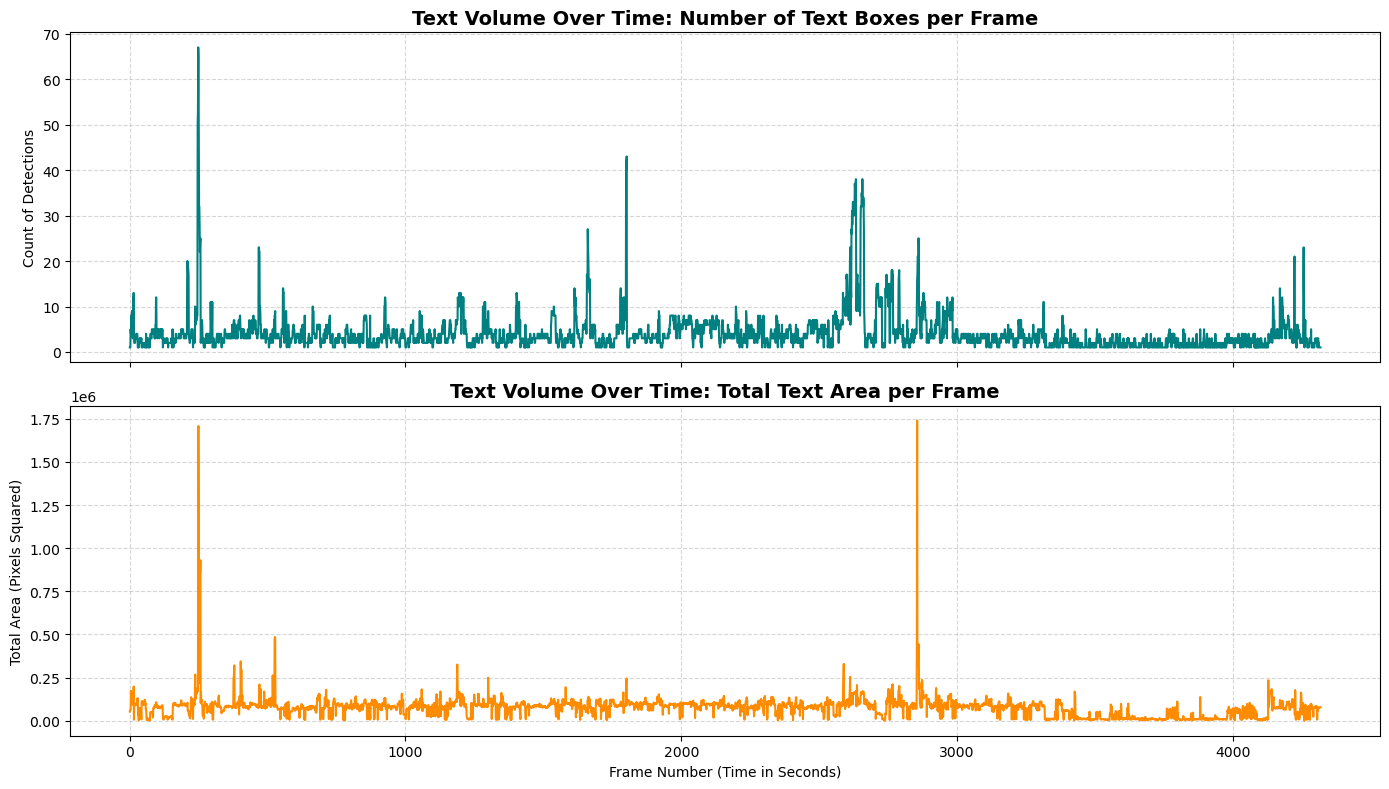

In [47]:
# group the data by Frame_Number
# Count how many text detections there are per frame
text_counts = df_cleaned.groupby('frame_n').size()

# Sum the total area of all text detections per frame
text_areas = df_cleaned.groupby('frame_n')['area'].sum()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# number of Detections 
ax1.plot(text_counts.index, text_counts.values, color='teal', linewidth=1.5)
ax1.set_title('Text Volume Over Time: Number of Text Boxes per Frame', fontsize=14, fontweight='bold')
ax1.set_ylabel('Count of Detections')
ax1.grid(True, linestyle='--', alpha=0.5)

# Total Area 
ax2.plot(text_areas.index, text_areas.values, color='darkorange', linewidth=1.5)
ax2.set_title('Text Volume Over Time: Total Text Area per Frame', fontsize=14, fontweight='bold')
ax2.set_xlabel('Frame Number (Time in Seconds)')
ax2.set_ylabel('Total Area (Pixels Squared)')
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### Check one frame


Detected text:
NOTÍCIA TVI; confidence 0.5616670090418595
<b>EXCLUSIVO TVI</b>; confidence 0.9724684392704683
<b>tvi</b><br>19:55; confidence 0.8689554608785189
IGAS CONFIRMA INVESTIGAÇÃO AO DERMATOLOGISTA DO STª Mª; confidence 0.9514794477394649


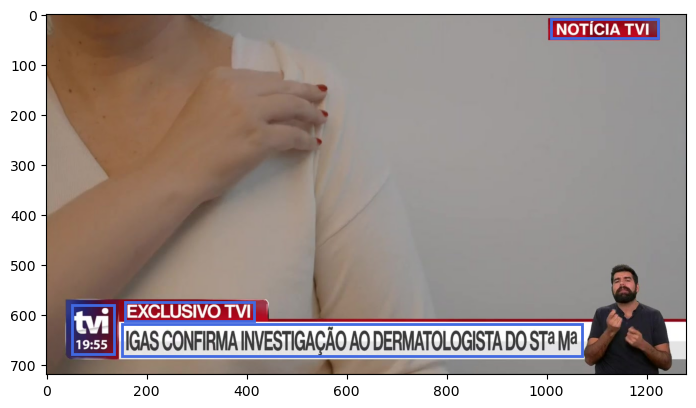

In [48]:
frame = 100

frame_id = data.iloc[frame]['Frame']
#print(frame_id)

img = Image.open(os.path.join('..', frame_id))

fig = plt.figure()
ax = fig.add_axes([0, 0, 1, 1])
ax.imshow(img)

print("\nDetected text:")

for t in data.iloc[frame]['OCR']:

    box = t['bbox']
    # Create a rectangle patch
    rect = patches.Rectangle((box[0], box[1]), box[2]-box[0], box[3]-box[1], linewidth=2, edgecolor='royalblue', facecolor='none')

    # Add patch to the image
    ax.add_patch(rect)

    print(f"{t['text']}; confidence {t['conf']}")
